In [ ]:
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os
import random
import seaborn as sns
from collections import defaultdict

# Replaces google.colab.patches
def cv2_imshow(img):
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.show()

In [56]:
import kagglehub

path = kagglehub.dataset_download("abrars2/fruit-quality-classificaltion-and-detection")
print("Path to dataset files:", path)

Path to dataset files: /Users/1an/.cache/kagglehub/datasets/abrars2/fruit-quality-classificaltion-and-detection/versions/1


In [57]:
main_path = os.path.join(path, 'Fruit Quality Classification')

train_image_dir = os.path.join(main_path, 'train', 'images')
train_label_dir = os.path.join(main_path, 'train', 'labels')
valid_image_dir = os.path.join(main_path, 'valid', 'images')
valid_label_dir = os.path.join(main_path, 'valid', 'labels')

print(os.path.exists(train_image_dir)) 
print(os.path.exists(valid_image_dir))  

print('train image directory' + train_image_dir)

True
True
train image directory/Users/1an/.cache/kagglehub/datasets/abrars2/fruit-quality-classificaltion-and-detection/versions/1/Fruit Quality Classification/train/images


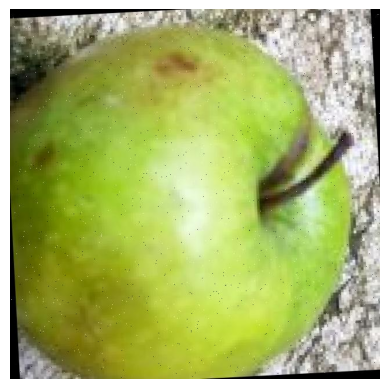

In [58]:
test_img = cv2.imread(train_image_dir + '/20190809_122412_jpg.rf.6ae3441a3996044cc318aa57961deeeb.jpg')

cv2_imshow(test_img)

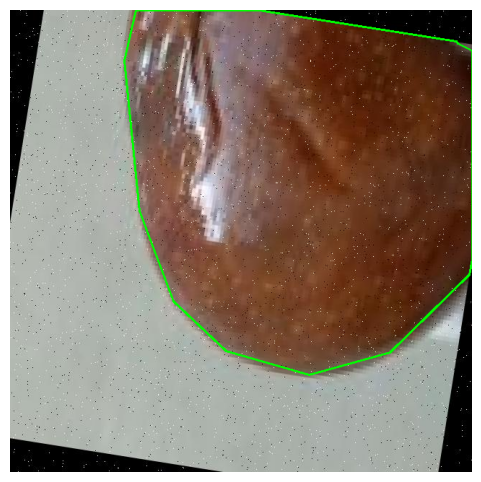

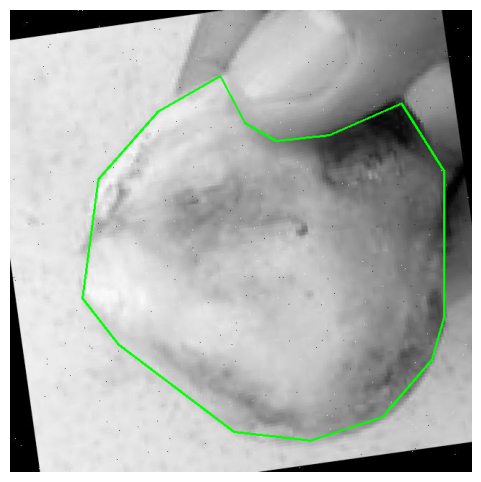

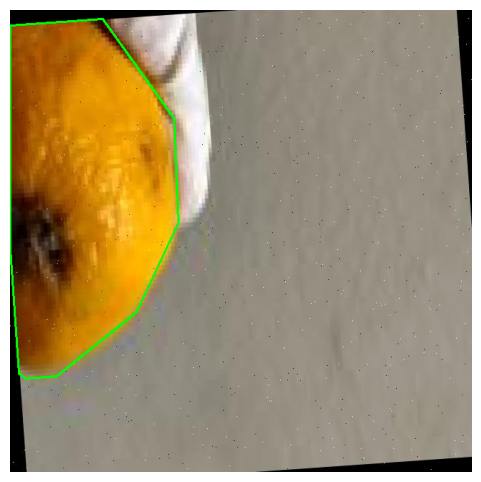

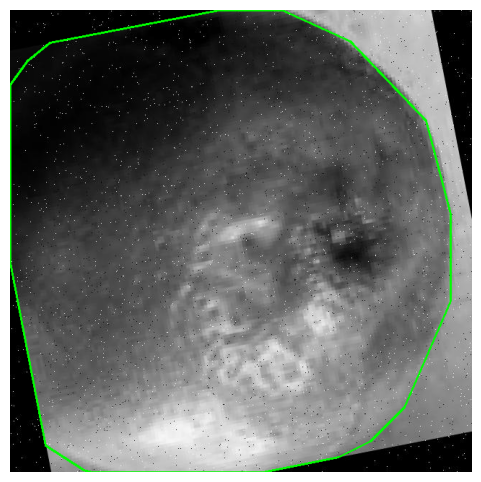

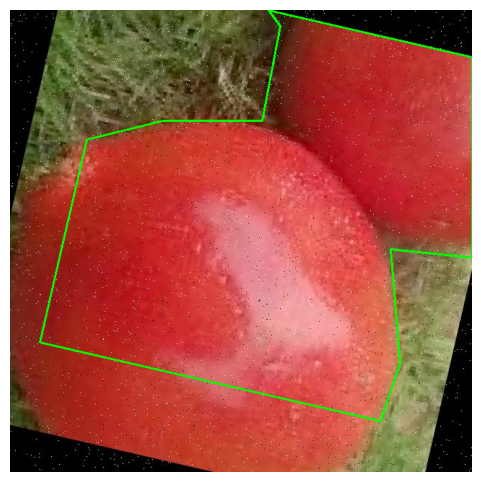

In [59]:
num_samples = 5

image_files = [f for f in os.listdir(train_image_dir) if f.endswith((".jpg", ".png"))]
samples = random.sample(image_files, num_samples)

for img_file in samples:

    img_path = os.path.join(train_image_dir, img_file)
    label_path = os.path.join(train_label_dir, img_file.replace(".jpg", ".txt").replace(".png", ".txt"))

    img = cv2.imread(img_path)
    h, w = img.shape[:2]

    if os.path.exists(label_path):

        with open(label_path) as f:
            for line in f:

                values = list(map(float, line.split()))
                class_id = int(values[0])
                coords = values[1:]
                points = []

                for i in range(0, len(coords), 2):
                    x = int(coords[i] * w)
                    y = int(coords[i+1] * h)
                    points.append([x,y])

                points = np.array(points, dtype=np.int32)

                cv2.polylines(img, [points], True, (0,255,0), 2)

    plt.figure(figsize=(6,6))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()

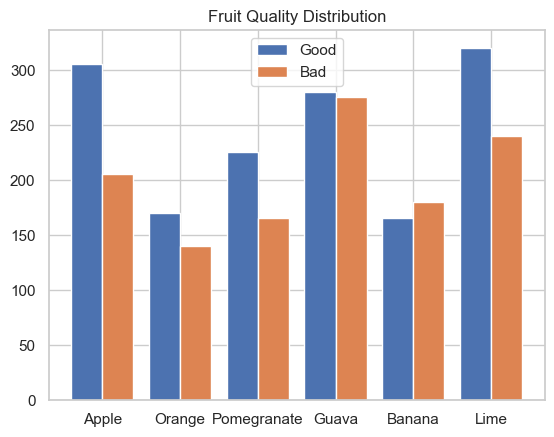

In [60]:
class_counts = defaultdict(int)

for file in os.listdir(train_label_dir):
    if file.endswith(".txt"):
        with open(os.path.join(train_label_dir, file)) as f:
            for line in f:
                class_id = int(line.split()[0])   # first number
                class_counts[class_id] += 1

class_names = {
    0: "Bad_Apple",
    1: "Bad_Banana",
    2: "Bad_Guava",
    3: "Bad_Lime",
    4: "Bad_Orange",
    5: "Bad_Pomegranate",
    6: "Good_Apple",
    7: "Good_Banana",
    8: "Good_Guava",
    9: "Good_Lime",
    10: "Good_Lime2",
    11: "Good_Orange",
    12: "Good_Pomegranate",
    13: "Good_Pomegranate2"
}

fruit_counts = defaultdict(lambda: {"Good":0, "Bad":0})

for class_id, count in class_counts.items():

    name = class_names.get(class_id)

    if name is None:
        continue

    quality, fruit = name.split("_")

    fruit = fruit.replace("2","")   # removes Lime2 duplicate

    fruit_counts[fruit][quality] += count


fruit_counts = defaultdict(lambda: {"Good":0,"Bad":0})

for file in os.listdir(train_label_dir):
    if file.endswith(".txt"):
        for line in open(os.path.join(train_label_dir,file)):
            cid = int(line.split()[0])
            q,f = class_names[cid].split("_")
            f = f.replace("2","")
            fruit_counts[f][q] += 1

fruits = list(fruit_counts.keys())
good = [fruit_counts[f]["Good"] for f in fruits]
bad = [fruit_counts[f]["Bad"] for f in fruits]

x = np.arange(len(fruits))
plt.bar(x-0.2,good,0.4,label="Good")
plt.bar(x+0.2,bad,0.4,label="Bad")
plt.xticks(x,fruits)
plt.title("Fruit Quality Distribution")
plt.legend()
plt.show()

In [61]:
data = []

for file in os.listdir(train_label_dir):

    if not file.endswith(".txt"):
        continue

    label_path = os.path.join(train_label_dir, file)

    image_name = file.replace(".txt",".jpg")
    image_path = os.path.join(train_image_dir, image_name)

    if not os.path.exists(image_path):
        continue

    img = cv2.imread(image_path)

    if img is None:
        continue

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    brightness = np.mean(gray)
    variance = np.var(gray)

    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    saturation = np.mean(hsv[:, :, 1])

    for line in open(label_path):

        cid = int(line.split()[0])

        q,f = class_names[cid].split("_")
        f = f.replace("2","")

        data.append({
            "fruit": f,
            "quality": q,
            "brightness": brightness,
            "variance": variance,
            "saturation": saturation
        })

df = pd.DataFrame(data)

print(df.head())

         fruit quality  brightness     variance  saturation
0        Apple    Good   96.019551  1826.478221  169.629377
1       Orange     Bad  122.418093  2532.215415  230.959910
2       Orange     Bad  122.418093  2532.215415  230.959910
3  Pomegranate     Bad  124.035195  2970.086691   90.704360
4  Pomegranate    Good  100.962295  3002.384999  157.623452


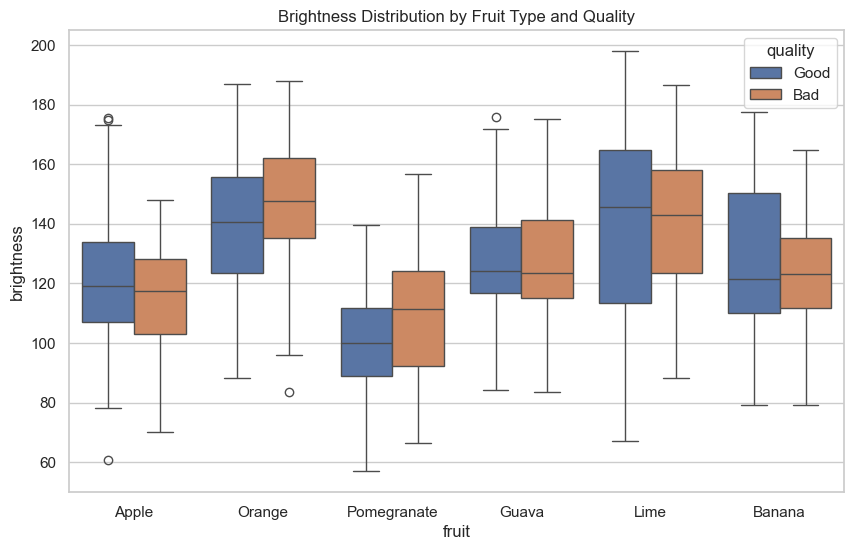

In [62]:
sns.set(style="whitegrid")

plt.figure(figsize=(10,6))

sns.boxplot(
    x="fruit",
    y="brightness",
    hue="quality",
    data=df
)

plt.title("Brightness Distribution by Fruit Type and Quality")
plt.show()

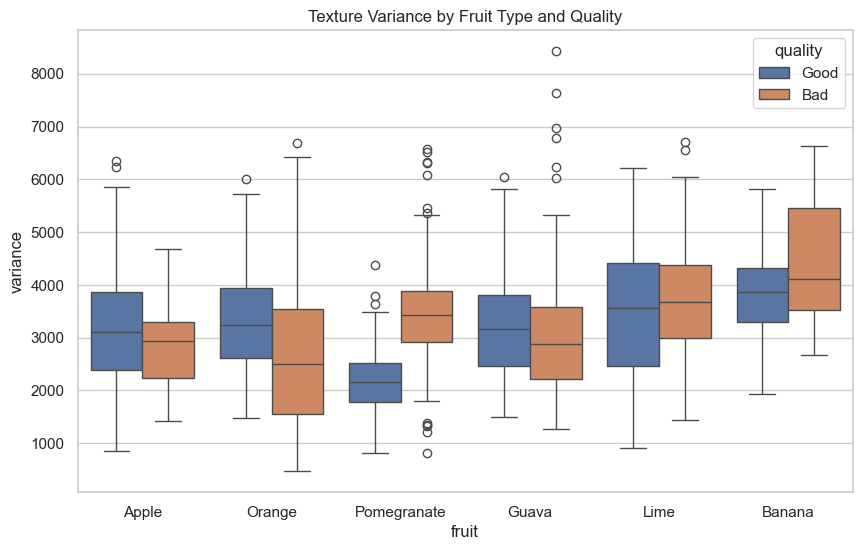

In [63]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x="fruit",
    y="variance",
    hue="quality",
    data=df
)

plt.title("Texture Variance by Fruit Type and Quality")
plt.show()

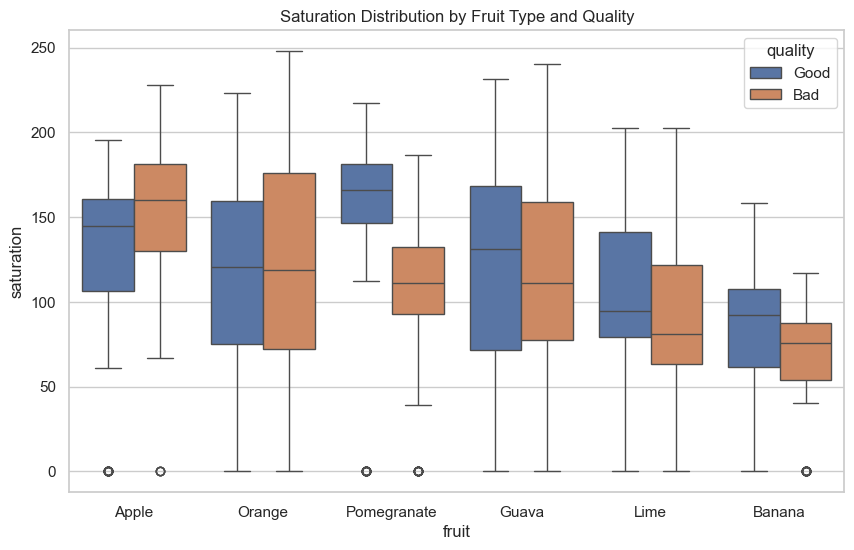

In [64]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x="fruit",
    y="saturation",
    hue="quality",
    data=df
)

plt.title("Saturation Distribution by Fruit Type and Quality")
plt.show()

   class_id  shape_score  color_score
0        12     0.000000     0.223369
1         6     0.859934     0.177214
2        10     0.946233     0.177267
3         6     0.926947     0.121560
4        11     0.943567     0.167508


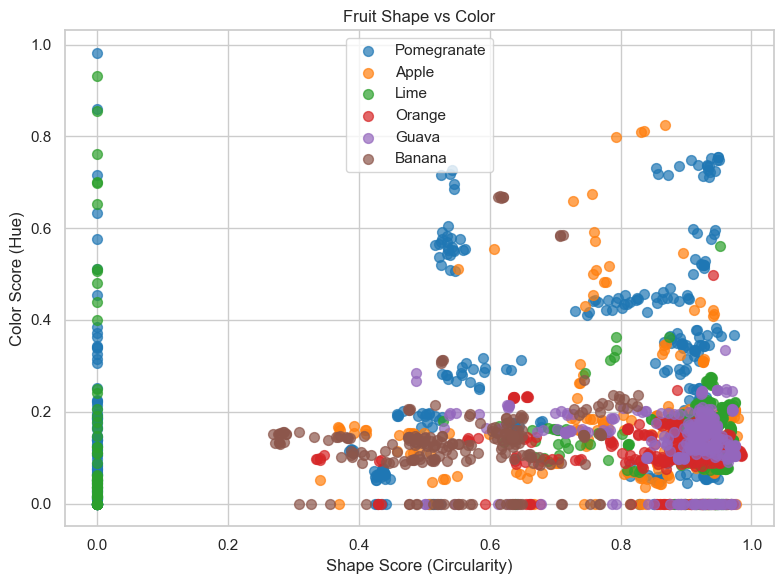

In [65]:
# compute color score based on color of pixels in shape converted to HSV
def create_fruit_mask(coords, image_shape):
    mask = np.zeros(image_shape[:2], dtype=np.uint8)
    points = np.array(coords, dtype=np.int32)
    cv2.fillPoly(mask, [points], 255)  # fill inside the boundary with white
    return mask

def extract_fruit_pixels(image, mask):
    # Only keep pixels where mask is white (inside the fruit boundary)
    fruit_pixels = image[mask == 255]  # shape: (N, 3) — N pixels, each with RGB
    return fruit_pixels

def compute_color_score(image, coords):
    mask = create_fruit_mask(coords, image.shape)
    fruit_pixels = extract_fruit_pixels(image, mask)

    fruit_pixels_hsv = cv2.cvtColor(
        fruit_pixels.reshape(1, -1, 3),
        cv2.COLOR_RGB2HSV
    )

    # Extract hue channel (0-180 in OpenCV)
    hue_values = fruit_pixels_hsv[0, :, 0]

    # Compute mean hue and normalize to 0-1
    mean_hue = np.mean(hue_values)
    color_score = mean_hue / 180.0  #
    return color_score

def compute_circularity(points):
    # Calculate area of the polygon using Shoelace formula
    area = 0.5 * np.abs(np.dot(points[:,0], np.roll(points[:,1], 1)) - np.dot(points[:,1], np.roll(points[:,0], 1)))

    # Calculate perimeter of the polygon
    perimeter = 0
    for i in range(len(points)):
        p1 = points[i]
        p2 = points[(i + 1) % len(points)]
        perimeter += np.linalg.norm(p1 - p2)

    if perimeter == 0:
        return 0

    # Circularity formula: C = (4 * pi * A) / P^2
    circularity = (4 * np.pi * area) / (perimeter ** 2)
    return circularity

df = pd.DataFrame(columns=["class_id", "shape_score", "color_score"])

for j in range(len(image_files)):  # len(image_files)
  image_path = os.path.join(train_image_dir, image_files[j])
  label_path = os.path.join(train_label_dir, image_files[j].replace(".jpg", ".txt").replace(".png", ".txt"))

  img = cv2.imread(image_path)
  img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
  h, w = img.shape[:2]

  with open(label_path) as f:
    for line in f:
      values = list(map(float, line.split()))
      class_id = int(values[0])
      original_coords = values[1:]

      points = []
      for i in range(0, len(original_coords), 2):
        x = int(original_coords[i] * w)
        y = int(original_coords[i+1] * h)
        points.append([x,y])
      points = np.array(points, dtype=np.int32)


  shape_score = compute_circularity(points)
  color_score = compute_color_score(img, points)

  img_info = [class_id, shape_score, color_score]
  df.loc[j] = img_info

df['class_id'] = df['class_id'].astype(int)
print(df.head())



# map each class_id to just the fruit name
fruit_map = {
    0:  'Apple',
    1:  'Banana',
    2:  'Guava',
    3:  'Lime',
    4:  'Orange',
    5:  'Pomegranate',
    6:  'Apple',
    7:  'Banana',
    8:  'Guava',
    9:  'Lime',
    10: 'Lime',
    11: 'Orange',
    12: 'Pomegranate',
    13: 'Pomegranate'
}

# add a new column to your dataframe
df['fruit'] = df['class_id'].map(fruit_map)
fruits = df['fruit'].unique()

classes = df['class_id'].unique()
colors = plt.cm.tab10.colors  # 10 distinct colors

plt.figure(figsize=(8, 6))

for i, fruit in enumerate(fruits):
    subset = df[df['fruit'] == fruit]
    plt.scatter(
        subset['shape_score'],
        subset['color_score'],
        color=colors[i],
        label=fruit,
        alpha=0.7,
        s=50
    )

plt.xlabel('Shape Score (Circularity)')
plt.ylabel('Color Score (Hue)')
plt.title('Fruit Shape vs Color')
plt.legend()
plt.tight_layout()
plt.show()

Shape of dataframe with outliers: (1852, 4)
Shape of dataframe with outliers: (1713, 4)


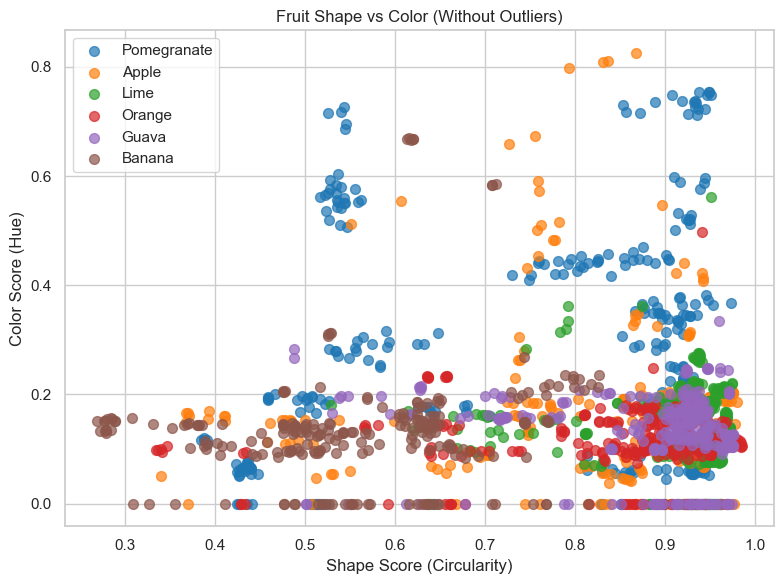

In [66]:
without_outliers = df[df['shape_score'] > 0]
print('Shape of dataframe with outliers:', df.shape)
print('Shape of dataframe with outliers:', without_outliers.shape)

plt.figure(figsize=(8, 6))

for i, fruit in enumerate(fruits):
    subset = without_outliers [without_outliers ['fruit'] == fruit]
    plt.scatter(
        subset['shape_score'],
        subset['color_score'],
        color=colors[i],
        label=fruit,
        alpha=0.7,
        s=50
    )

plt.xlabel('Shape Score (Circularity)')
plt.ylabel('Color Score (Hue)')
plt.title('Fruit Shape vs Color (Without Outliers)')
plt.legend()
plt.tight_layout()
plt.show()